### Research course submission

**Name :** Abhijith Sreesylesh Babu

**Paper :** Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods



# Probabilistic outputs for support vector machines

The outputs of a support vector machines are not probabilities, which makes it hard to use them in a large decision making system. Here, our aim is to convert the outputs of a SVM into a probability distribution of the classes.


### Support vector machines

Support vector machines are classification models that finds the maximaum marginal hyperplane between two classes of data. The input x of n dimensions are mapped into vectors in an n dimensional space. SVM aims to find a hyperplane (a geometry of n-1 dimensions) that separates the input vectors such that the vectors of same class goes to the same side of the hyperplane. The margin of the hyperplane is maximized so that there is maximum distance between the hyperplane and the nearest point on either sides (nearest point considered in case of non-separable data)

The decision fucntion of the SVM gives the distance of the point from the hyperplane. It will be positive for one class and negative for another class. Our aim is to get the probabilities of the input being in either class.

### Approach

According to this paper, we are attaching a sigmoid function on the output of the SVM that calculates the probability of the two classes

In [1]:
# importing the required libraries

import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import math

In [2]:
# importing an SVM model from svm classifiers (SVC) in skikit learn

svm = SVC(kernel="linear", C=1.0, probability=False)

In [3]:
# creating a random dataset for classification using the make_classification function in sklearn

X,Y = make_classification(n_samples=1000, n_features=10, random_state=4)

# Converting Y into {-1, 1} from {0, 1} since the SVM expects the labels to be {-1, 1}

Y = 2*Y - 1

In [4]:
# Fitting the SVM model with the data

svm.fit(X, Y)

# Calculating the decision function output of the SVM model

decision_output = svm.decision_function(X)

### Attaching a sigmoid function

We use the values of decision function in a sigmoid function to create the probabilities. The function will be of the form 1/(1 + e^(Af + B)). Here A and B are parameters of the sigmoid

In [5]:
# converting the labels to {0, 1} for ease of calculation

Y = (Y + 1)/2

In [6]:
# finding the value of the parameters using model-trust algorithm based on Levenberg-Marquardt algorithm as mentioned in the paper

sig_size = len(Y)
prior1 = sum(Y)
prior0 = sig_size - prior1


A = 0
B = math.log((prior0 + 1) / (prior1 + 1))
hiTarget = (prior1 + 1) / (prior1 + 2)
loTarget = 1 / (prior0 + 2)
lambda_ = 1e-3
olderr = 1e300
pp = [(prior1+1)/(prior0+prior1+2) for i in range(sig_size)]
count = 0
for it in range(100):
    a,b,c,d,e = 0,0,0,0,0
    for i in range(sig_size):
        if Y[i]:
            t = hiTarget
        else:
            t = loTarget
        d1 = pp[i] - t
        d2 = pp[i] * (1 - pp[i])
        a += decision_output[i] * decision_output[i] * d2
        b += d2
        c += decision_output[i] * d2
        d += decision_output[i] * d1
        e += d1
    if abs(d) < 1e-9 and abs(a) < 1e-9:
        break
    oldA = A
    oldB = B
    err = 0
    while True:
        det = (a+lambda_)*(b+lambda_)-c*c
        if det == 0:
            lambda_ *= 10
            continue
        A = oldA + ((b+lambda_)*d-c*e)/det
        B = oldB + ((a+lambda_)*e-c*d)/det
        err = 0
        for i in range(sig_size):
            p = 1/(1+math.exp((decision_output[i]*A) + B))
            pp[i] = p
            err -= t*math.log(p)+(1-t)*math.log(1-p)    
        if err < olderr*(1+1e-7):
            lambda_ *= 0.1 
            break
        lambda_ *= 10
        if lambda_ > 1e6:
            break
    diff = err - olderr
    scale = 0.5*(err+olderr+1)
    if diff > -1e-3*scale and diff < 1e-7*scale:
        count += 1
    else:
        count = 0
    olderr = err
    if count == 3:
            break


In [7]:
# Parameters of the sigmoid function

print("A: ", A)
print("B: ", B)

A:  -0.6597939627553993
B:  -0.16549383614309807


In [8]:
# finding the probability of the data points belonging to class 1
probabilities = []
for i in decision_output:
    probabilities.append(1/(1+math.exp((i*A) + B)))

In [9]:
print(probabilities)

[0.7333490264425129, 0.15418484142198943, 0.8821437679827253, 0.8083343752123049, 0.76053283189825, 0.041177740138404924, 0.17235465615994447, 0.42402653845942145, 0.8061487607658284, 0.2684077809820041, 0.2618079990040069, 0.4276869944009426, 0.6736925443032173, 0.9216118839286586, 0.8833103465196405, 0.677152558547685, 0.34187274036875326, 0.09635128031355557, 0.7794681607632794, 0.14480915489515608, 0.9809166100429383, 0.8907100833393707, 0.8530173534514971, 0.898591773956494, 0.6913843761393336, 0.42394819529922684, 0.8560278515421698, 0.04712618599721559, 0.21452277200227587, 0.452445373074755, 0.7795392963795398, 0.6305093937994565, 0.32942576747623753, 0.768525271070452, 0.9571118478000594, 0.15528671187480525, 0.1662518484948193, 0.8458675855774067, 0.6414942917725857, 0.7942007441797175, 0.3962386601528904, 0.3259474283669153, 0.3415336821520057, 0.591142243675969, 0.19310249072174823, 0.7852243801595059, 0.8316787168402187, 0.9532861585895329, 0.8294946669216211, 0.8419453161

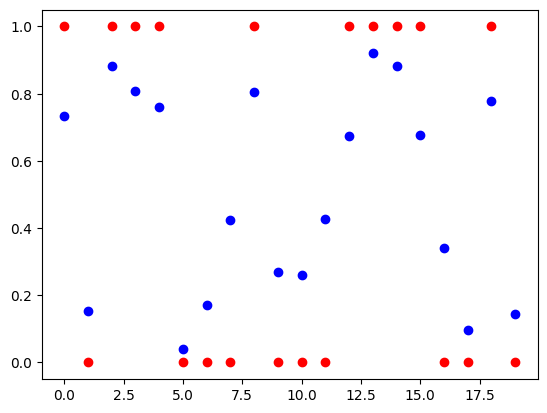

In [10]:
# plotting the outputs and the predicted probabilities of the first 20 data points

n_points = 20
plt.scatter(range(n_points), Y[:n_points], color='red')
plt.scatter(range(n_points), probabilities[:n_points], color='blue')
plt.show()

Here we can see that we found probability values for class 1. If the data actually belongs to class 1, then the probabilities are higher while if the data belongs to class 0, the probabilities are lower